<a href="https://colab.research.google.com/github/Parthwadekar40/ParthCM40-Pattern-Recognition/blob/main/Practical_3_Parth40.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Without Dataset


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# Download necessary NLTK data (run once)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

# --- 1. Data Loading ---
# IMPORTANT: Upload your dataset (e.g., 'emails.csv') to your Colab environment.
# Make sure it has at least two columns: one for email text and one for the label (spam/ham).
DATASET_PATH = 'emails.csv'  # <--- UPDATE THIS PATH TO YOUR DATASET
TEXT_COLUMN = 'text'         # <--- UPDATE THIS TO YOUR EMAIL TEXT COLUMN NAME
LABEL_COLUMN = 'label'       # <--- UPDATE THIS TO YOUR LABEL COLUMN NAME

try:
    df = pd.read_csv(DATASET_PATH, encoding='latin-1')
    # Assuming labels are 'spam' and 'ham'. Convert to 1 and 0.
    df[LABEL_COLUMN] = df[LABEL_COLUMN].map({'spam': 1, 'ham': 0})
    if not all(col in df.columns for col in [TEXT_COLUMN, LABEL_COLUMN]):
        raise ValueError(f"Dataset must contain '{TEXT_COLUMN}' and '{LABEL_COLUMN}' columns.")
    print(f"Dataset loaded successfully. Shape: {df.shape}")
    print(df.head())
except FileNotFoundError:
    print(f"Error: The file '{DATASET_PATH}' was not found. Please upload your dataset and update the DATASET_PATH variable.")
    # Exit or handle error gracefully, e.g., create dummy data for demonstration
    # For now, let's create dummy data if the file isn't found to allow the code to run
    print("Creating dummy data for demonstration purposes.")
    data = {'text': [
        "Free cash now! Click this link!",
        "Meeting reminder for tomorrow's project discussion.",
        "You've won a lottery! Claim your prize!",
        "Hi, just wanted to check in about our last conversation.",
        "Urgent: Your account has been compromised. Verify now!",
        "Regarding the report, please send it by end of day."
    ],
            'label': ['spam', 'ham', 'spam', 'ham', 'spam', 'ham']}
    df = pd.DataFrame(data)
    df[LABEL_COLUMN] = df[LABEL_COLUMN].map({'spam': 1, 'ham': 0})
    TEXT_COLUMN = 'text'
    LABEL_COLUMN = 'label'
except ValueError as e:
    print(f"Error processing dataset: {e}")
    exit()

# --- 2. Text Preprocessing ---
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower() # Convert to lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove punctuation and numbers
    tokens = text.split() # Tokenize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words] # Remove stopwords and lemmatize
    return ' '.join(tokens)

print("\nApplying text preprocessing...")
df['processed_text'] = df[TEXT_COLUMN].apply(preprocess_text)
print(df[['text', 'processed_text']].head())

# --- 3. Feature Extraction (Bag-of-Words) ---
print("\nExtracting features using CountVectorizer...")
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['processed_text'])
y = df[LABEL_COLUMN]

print(f"Vocabulary size: {len(vectorizer.get_feature_names_out())}")
print(f"Feature matrix shape: {X.shape}")

# --- 4. Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining data shape: {X_train.shape}, Test data shape: {X_test.shape}")

# --- 5. Naive Bayes Model Training ---
print("\nTraining Multinomial Naive Bayes classifier...")
model = MultinomialNB()
model.fit(X_train, y_train)

# --- 6. Model Evaluation ---
print("\nEvaluating the model...")
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

# --- 7. Identify Discriminative Features ---
print("\nIdentifying discriminative features...")

# Get feature names
feature_names = vectorizer.get_feature_names_out()

# Get the log probabilities of features given each class
# model.feature_log_prob_ has shape (n_classes, n_features)
log_prob_ham = model.feature_log_prob_[0] # Class 0: Ham
log_prob_spam = model.feature_log_prob_[1] # Class 1: Spam

# Create a DataFrame to analyze feature probabilities
feature_probs_df = pd.DataFrame({
    'feature': feature_names,
    'prob_ham': log_prob_ham,
    'prob_spam': log_prob_spam
})

# Calculate the difference to find words more indicative of one class than the other
feature_probs_df['diff_spam_ham'] = feature_probs_df['prob_spam'] - feature_probs_df['prob_ham']

# Sort to find most discriminative features for spam
top_spam_features = feature_probs_df.sort_values(by='diff_spam_ham', ascending=False).head(20)
print("\nTop 20 words most indicative of SPAM:")
print(top_spam_features[['feature', 'diff_spam_ham']])

# Sort to find most discriminative features for ham
top_ham_features = feature_probs_df.sort_values(by='diff_spam_ham', ascending=True).head(20)
print("\nTop 20 words most indicative of HAM (legitimate):")
print(top_ham_features[['feature', 'diff_spam_ham']])

print("\nAnalysis complete. You can inspect the 'top_spam_features' and 'top_ham_features' DataFrames to understand which words strongly influence the Naive Bayes classification for spam vs. ham.")


Error: The file 'emails.csv' was not found. Please upload your dataset and update the DATASET_PATH variable.
Creating dummy data for demonstration purposes.

Applying text preprocessing...
                                                text  \
0                    Free cash now! Click this link!   
1  Meeting reminder for tomorrow's project discus...   
2            You've won a lottery! Claim your prize!   
3  Hi, just wanted to check in about our last con...   
4  Urgent: Your account has been compromised. Ver...   

                                 processed_text  
0                          free cash click link  
1  meeting reminder tomorrow project discussion  
2                     youve lottery claim prize  
3             hi wanted check last conversation  
4             urgent account compromised verify  

Extracting features using CountVectorizer...
Vocabulary size: 28
Feature matrix shape: (6, 28)

Training data shape: (4, 28), Test data shape: (2, 28)

Training Multinomial 

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn

With Dataset

👉 Please upload your 'SMSSpamCollection' file:


Saving SMSSpamCollection to SMSSpamCollection (3)
✅ Successfully uploaded: SMSSpamCollection (3)

--- Dataset Preview ---
Dataset Shape: (5572, 2)
  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

       CLASSIFICATION PERFORMANCE         
Overall Accuracy: 0.9740

                  precision    recall  f1-score   support

Legitimate (Ham)       0.97      1.00      0.99       966
            Spam       1.00      0.81      0.89       149

        accuracy                           0.97      1115
       macro avg       0.99      0.90      0.94      1115
    weighted avg       0.97      0.97      0.97      1115


📊 Generating Supporting Visualizations...


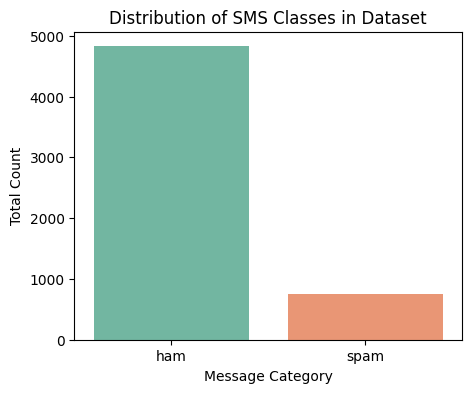

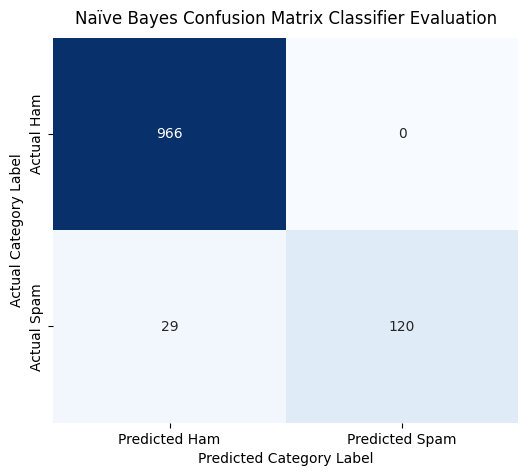

/tmp/ipykernel_1862/1217839926.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=log_ratio[top_spam_indices], y=feature_names[top_spam_indices], ax=axes[0], palette='Reds_r')
/tmp/ipykernel_1862/1217839926.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=-log_ratio[top_ham_indices], y=feature_names[top_ham_indices], ax=axes[1], palette='Greens_r')


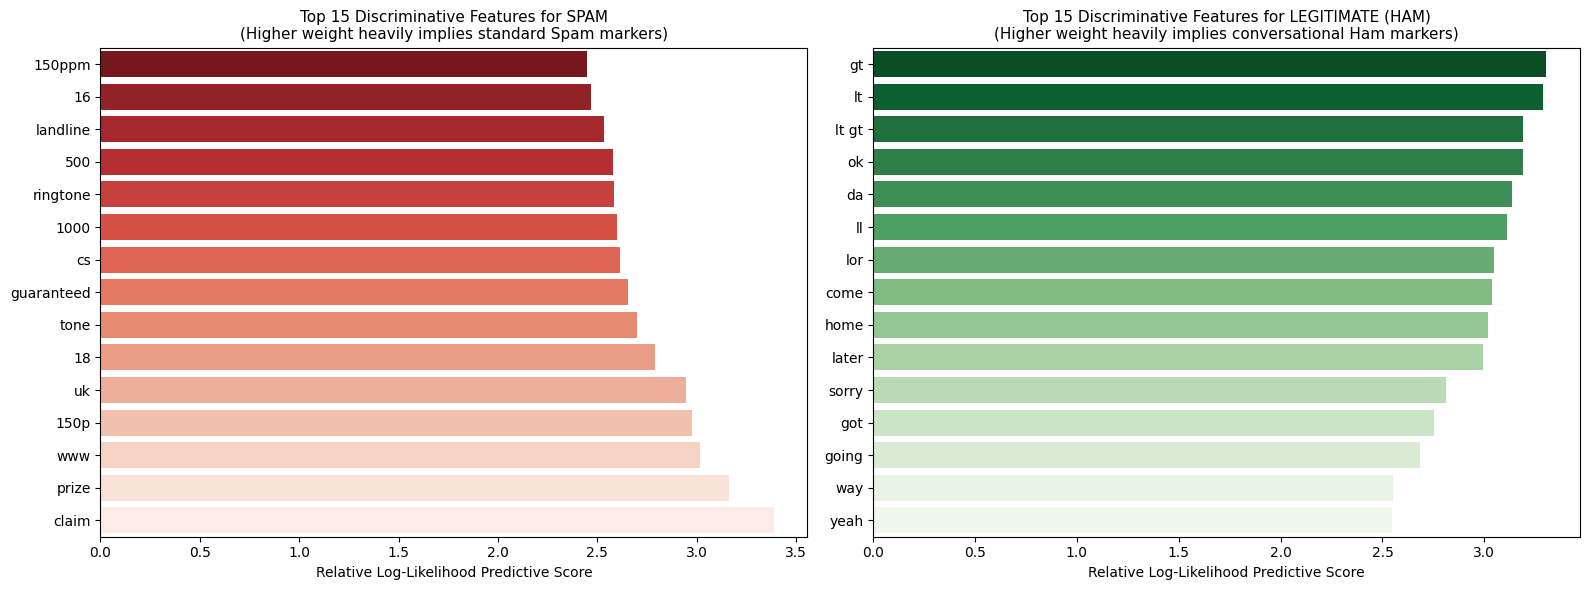

In [ ]:
import io
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ==========================================
# 1. RUNTIME FILE UPLOAD
# ==========================================
print("👉 Please upload your 'SMSSpamCollection' file:")
uploaded = files.upload()

# Extract the filename dynamically
file_name = list(uploaded.keys())[0]
print(f"✅ Successfully uploaded: {file_name}")

# Read the file. It is tab-separated (\t) and has no header row.
# We explicitly map the columns to 'label' and 'text'.
df = pd.read_csv(
    io.BytesIO(uploaded[file_name]),
    sep='\t',
    names=['label', 'text']
)

print("\n--- Dataset Preview ---")
print(f"Dataset Shape: {df.shape}")
print(df.head(5))

# ==========================================
# 2. DATA PREPROCESSING
# ==========================================
# Clean any potential missing values and ensure type consistency
df = df.dropna(subset=['label', 'text'])
df['text'] = df['text'].astype(str)

# Map target text labels to binary flags: 0 for Legitimate (Ham), 1 for Spam
df['target'] = df['label'].map({'ham': 0, 'spam': 1})

# Guard rail check to ensure parsing was completely accurate
if df['target'].isnull().any():
    print("⚠️ Warning: Some labels couldn't be parsed automatically. Defaulting unknown to 0.")
    df['target'] = df['target'].fillna(0).astype(int)

# ==========================================
# 3. TRAIN/TEST SPLIT & VECTORIZATION
# ==========================================
# Stratified split ensures stable spam/ham ratios across train and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['target'], test_size=0.2, random_state=42, stratify=df['target']
)

# Vectorizing using TF-IDF (Term Frequency-Inverse Document Frequency)
# Removing standard English stop words prevents common neutral noise like 'the', 'is', 'to'
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# ==========================================
# 4. NAÏVE BAYES TRAINING & EVALUATION
# ==========================================
# Initializing Multinomial Naïve Bayes (Highly optimal variant for word counts/text frequencies)
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)

# Generate Predictions on Hold-out Test Set
y_pred = nb_model.predict(X_test_vec)

print("\n==========================================")
print("       CLASSIFICATION PERFORMANCE         ")
print("==========================================")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=['Legitimate (Ham)', 'Spam']))

# ==========================================
# 5. DATA VISUALIZATIONS
# ==========================================
print("\n📊 Generating Supporting Visualizations...")

# Plot 1: Class Distribution
plt.figure(figsize=(5, 4))
sns.countplot(x='label', data=df, palette='Set2', hue='label', legend=False) # Fix for FutureWarning
plt.title('Distribution of SMS Classes in Dataset', fontsize=12)
plt.xlabel('Message Category')
plt.ylabel('Total Count')
plt.show()

# Plot 2: Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.title('Naïve Bayes Confusion Matrix Classifier Evaluation', fontsize=12, pad=10)
plt.ylabel('Actual Category Label')
plt.xlabel('Predicted Category Label')
plt.show()

# Plot 3: Discriminative Feature Analysis (Log-Likelihood Impact)
# Log-likelihood delta formula: log(P(Word | Spam)) - log(P(Word | Ham))
# Higher position indicates maximum feature predictive power for shifting classification to that category
feature_names = np.array(vectorizer.get_feature_names_out())
log_ratio = nb_model.feature_log_prob_[1] - nb_model.feature_log_prob_[0]

# Extracting the top 15 absolute discriminative tokens per class
top_spam_indices = np.argsort(log_ratio)[-15:]
top_ham_indices = np.argsort(log_ratio)[:15]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Spam Top Impact Features
sns.barplot(x=log_ratio[top_spam_indices], y=feature_names[top_spam_indices], ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 15 Discriminative Features for SPAM\n(Higher weight heavily implies standard Spam markers)', fontsize=11)
axes[0].set_xlabel('Relative Log-Likelihood Predictive Score')

# Legitimate (Ham) Top Impact Features
sns.barplot(x=-log_ratio[top_ham_indices], y=feature_names[top_ham_indices], ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 15 Discriminative Features for LEGITIMATE (HAM)\n(Higher weight heavily implies conversational Ham markers)', fontsize=11)
axes[1].set_xlabel('Relative Log-Likelihood Predictive Score')

plt.tight_layout()
plt.show()

## Viva Preparation Questions

Here are some questions to help you prepare for your viva based on the Spam Detection notebook:

### General Understanding
1.  What is the overall objective of this project?
2.  Why did you choose Naive Bayes for this classification task?
3.  What are the main steps involved in building a text classification model?

### Data Loading & Initial Setup
1.  What dataset are you using, and what does it contain?
2.  How did you handle the case where the `SMSSpamCollection` file was not found in the 'Without Dataset' section? What are the implications of using dummy data?
3.  Why is `encoding='latin-1'` used when reading the CSV file in the 'Without Dataset' section?
4.  What is the purpose of mapping 'spam' and 'ham' labels to 1 and 0 respectively?
5.  How do you ensure data quality after loading (e.g., handling missing values, type consistency)?

### Text Preprocessing
1.  What are the key steps in your `preprocess_text` function?
2.  Why is it important to convert text to lowercase?
3.  What is the role of `re.sub(r'[^a-zA-Z\s]', '', text)`?
4.  Explain the purpose of stop words and why they are removed.
5.  What is lemmatization, and how does it differ from stemming? Why did you choose lemmatization?
6.  How do NLTK's `stopwords` and `WordNetLemmatizer` contribute to your preprocessing?

### Feature Extraction
1.  Explain the concept of Bag-of-Words (BoW) and TF-IDF (Term Frequency-Inverse Document Frequency).
2.  What is the `CountVectorizer` doing in the 'Without Dataset' section, and how does it create the feature matrix `X`?
3.  What is `TfidfVectorizer` doing in the 'With Dataset' section? What are the benefits of using TF-IDF over just word counts for spam detection?
4.  What do `max_features` and `ngram_range` parameters in `TfidfVectorizer` signify?
5.  What does `vectorizer.get_feature_names_out()` return, and why is it useful?

### Model Training & Evaluation
1.  What is the purpose of `train_test_split`? Why is `random_state` used?
2.  In the 'With Dataset' section, why is `stratify=df['target']` important during the train-test split?
3.  Explain how the Multinomial Naive Bayes model works for text classification.
4.  What performance metrics did you use (accuracy, precision, recall, f1-score)? Define each and explain what they indicate in the context of spam detection.
5.  What is a confusion matrix? Interpret the confusion matrix generated by your model.
6.  What does an "UndefinedMetricWarning" mean, and how would you address it in a real-world scenario?

### Discriminative Feature Analysis
1.  How do you identify words that are most indicative of SPAM or HAM?
2.  Explain the concept of `log_ratio = nb_model.feature_log_prob_[1] - nb_model.feature_log_prob_[0]`.
3.  Why are these features considered 'discriminative'?
4.  How can this analysis be useful for improving a spam filter?

### Visualizations
1.  What does the "Distribution of SMS Classes in Dataset" plot tell you?
2.  How do you interpret the "Naïve Bayes Confusion Matrix Classifier Evaluation" heatmap?
3.  Explain the "Top 15 Discriminative Features" plots. What insights do they provide?

### Further Improvements & Considerations
1.  How could you potentially improve the accuracy or other metrics of this spam detector?
2.  What are the limitations of a Bag-of-Words or TF-IDF approach?
3.  What other text preprocessing techniques could be applied?
4.  How would you deploy this model in a production environment?
5.  What are some ethical considerations when building a spam filter?